# Tau-5* WT and W397A/W433A: current chemical-shift and SAXS results

Snapshot: 28 September 2026. **Exploratory results, not final selected or converged ensembles.**

GP + AR330–447 is modeled. Shift and helix displays cover AR330–446; GP has no shift restraints and terminal P447 is excluded. WT and AA use their own sequences, measured shifts, and SPARTA+ random-coil references. Sequence audits are included.

**Latest direct fits:** all available interior shifts, nonnegative weights summing to one, no entropy penalty, no SAXS restraint. Carbon residuals have equal ppm weighting; N/H scales balance nuclei, not acceptance tolerances. WT pools contain 300/250 candidates; AA 299/250. The first pools include 50/49 back-calculated helix supplements. Before/after comparisons use exactly the same candidates. These unequal interim sizes do not establish replicate convergence. Effective ensemble sizes are ~35–38, not the requested final ~500 structures.

**Earlier joint fits:** SAXS + shifts with entropy regularization, 500 pooled candidates per protein. These are historical comparisons; their tighter SAXS agreement is accompanied by weaker local shift agreement.

The larger 2,000-candidate base pools per replicate and helix-length supplements are still being calculated. This notebook freezes the displayed snapshot rather than silently including unfinished structures. No Ramachandran basin panels are shown.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
p = Path('snapshot_data.json')
if not p.exists(): p = Path('Chemical_shift_SAXS/snapshot_data.json')
data = json.loads(p.read_text())
colors = {'WT':'#2466a8', 'AA':'#d96727'}
nuclei = {'CA':'Cα','C':'C′','CB':'Cβ','N':'N','NH':'HN'}
def nums(rows,key): return np.array([float(r[key]) for r in rows])


## DSSP helicity versus D2D: before and after direct shift fitting
Solid curves: D2D. Dashed/dotted: ensembles 1/2. DSSP H/G/I corresponds to the simplified DSSP definition used in the 2022 paper.

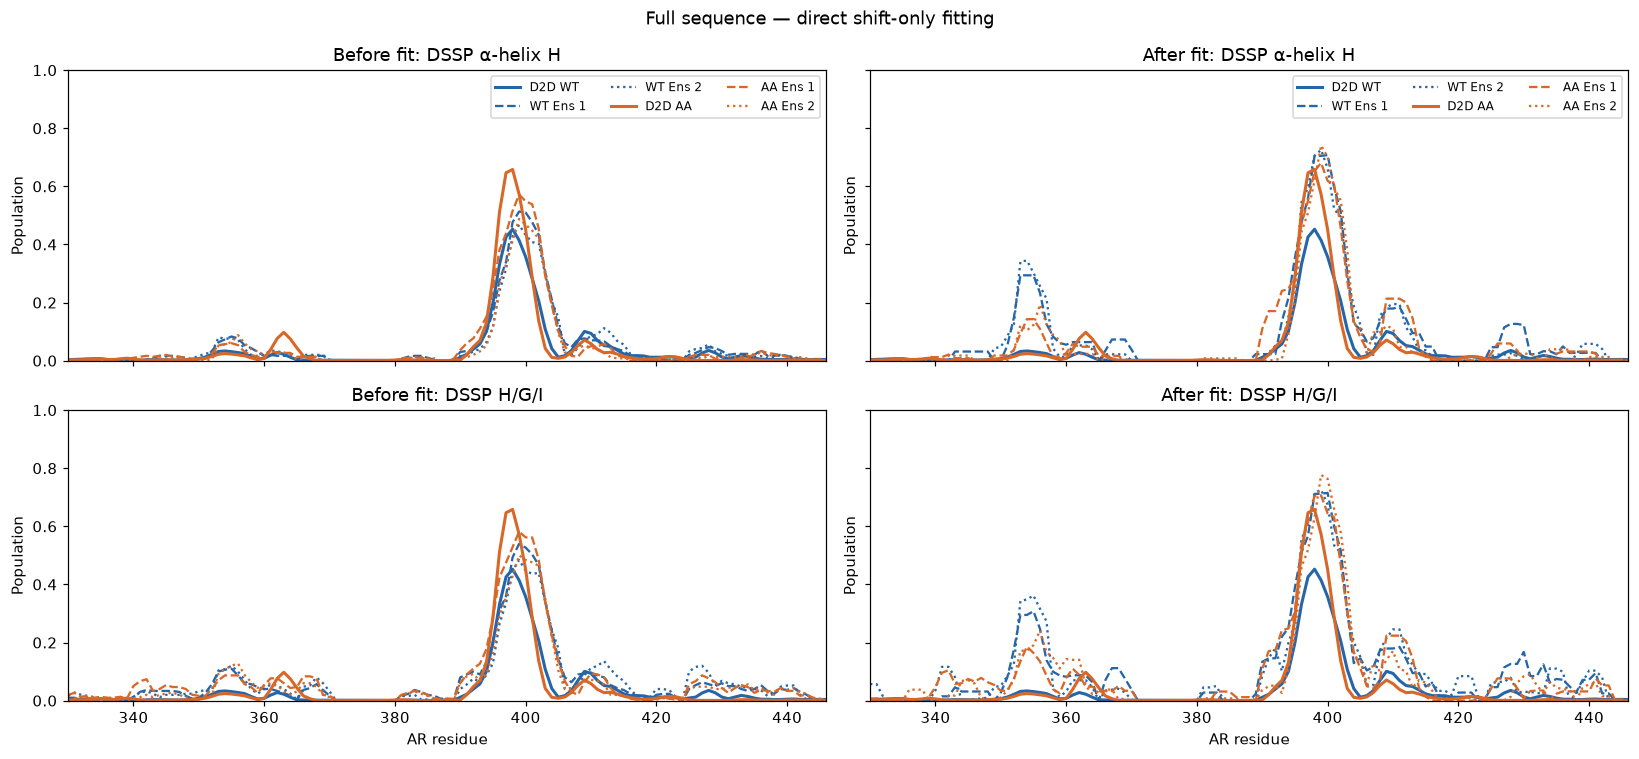

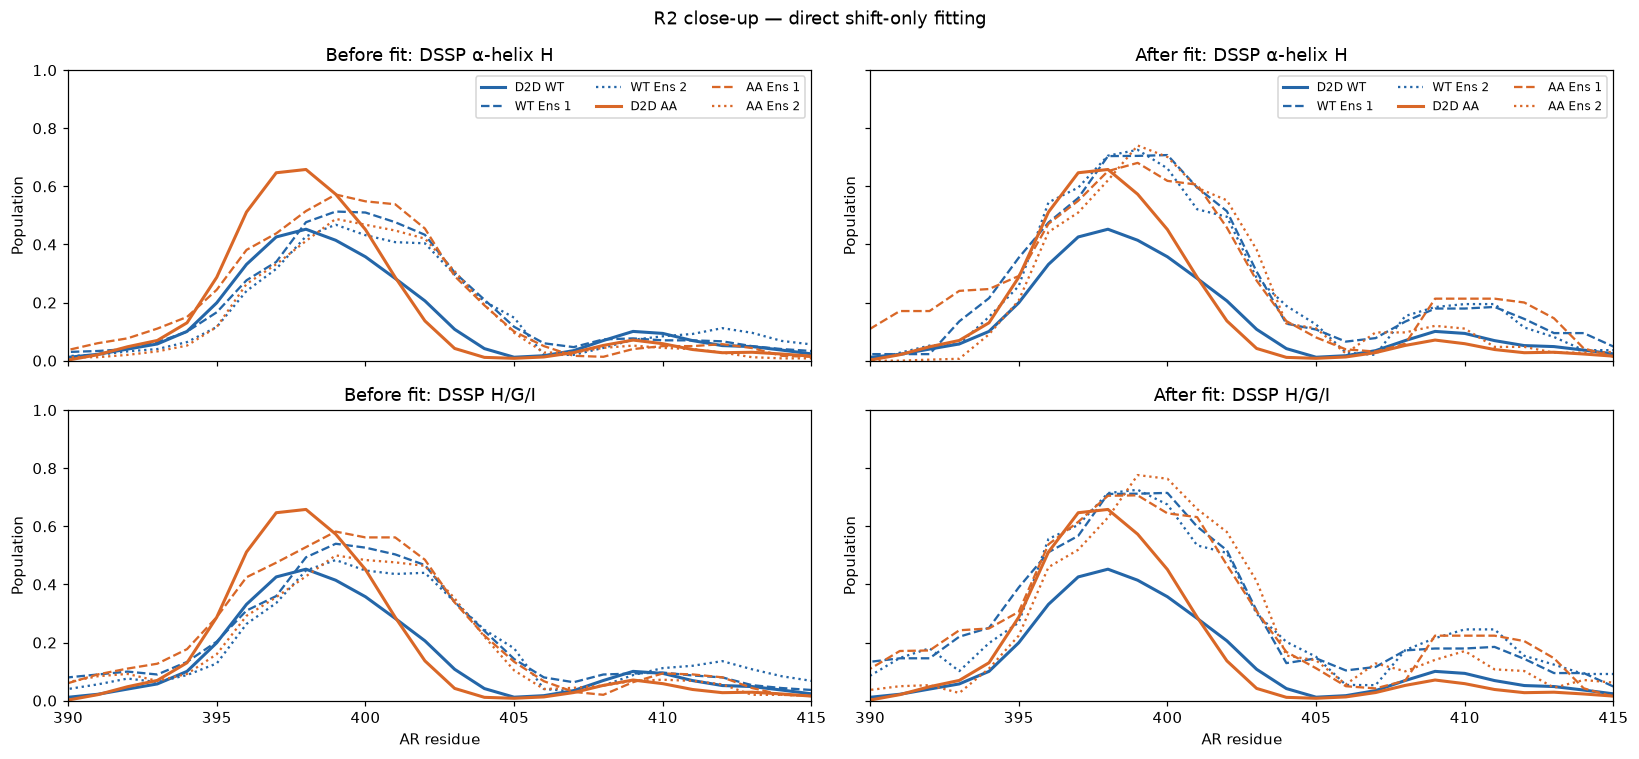

In [2]:
for limits, title in [((330,446),'Full sequence'), ((390,415),'R2 close-up')]:
    fig,axes=plt.subplots(2,2,figsize=(15,7),sharex=True,sharey=True)
    for col,stage in enumerate(['raw','fit']):
        for row,(definition,label) in enumerate([('DSSP_H','DSSP α-helix H'),('DSSP_HGI','DSSP H/G/I')]):
            ax=axes[row,col]
            for s in ['WT','AA']:
                d=data['d2d'][s];ax.plot(nums(d,'author_residue'),nums(d,'helix'),color=colors[s],lw=2,label='D2D '+s)
                for e,ls in [('1','--'),('2',':')]:
                    r=[r for r in data['helices'] if r['protein']==s and r['ensemble']==e and r['stage']==stage and r['definition']==definition]
                    ax.plot(nums(r,'AR_residue'),nums(r,'population'),color=colors[s],ls=ls,label=s+' Ens '+e)
            ax.set(xlim=limits,ylim=(0,1),ylabel='Population',title=('Before fit: ' if stage=='raw' else 'After fit: ')+label)
            if row==0:ax.legend(ncol=3,fontsize=8)
            if row==1:ax.set_xlabel('AR residue')
    fig.suptitle(title+' — direct shift-only fitting');fig.tight_layout()
plt.show()


## Experimental, raw, and fitted secondary shifts
Δδ = SHIFT − SPARTA+ RC_SHIFT. The same sequence-specific RC_SHIFT is subtracted from experiment and prediction; hence residuals equal the raw-shift residuals. All measured nuclei are included; missing shifts are not treated as zero.

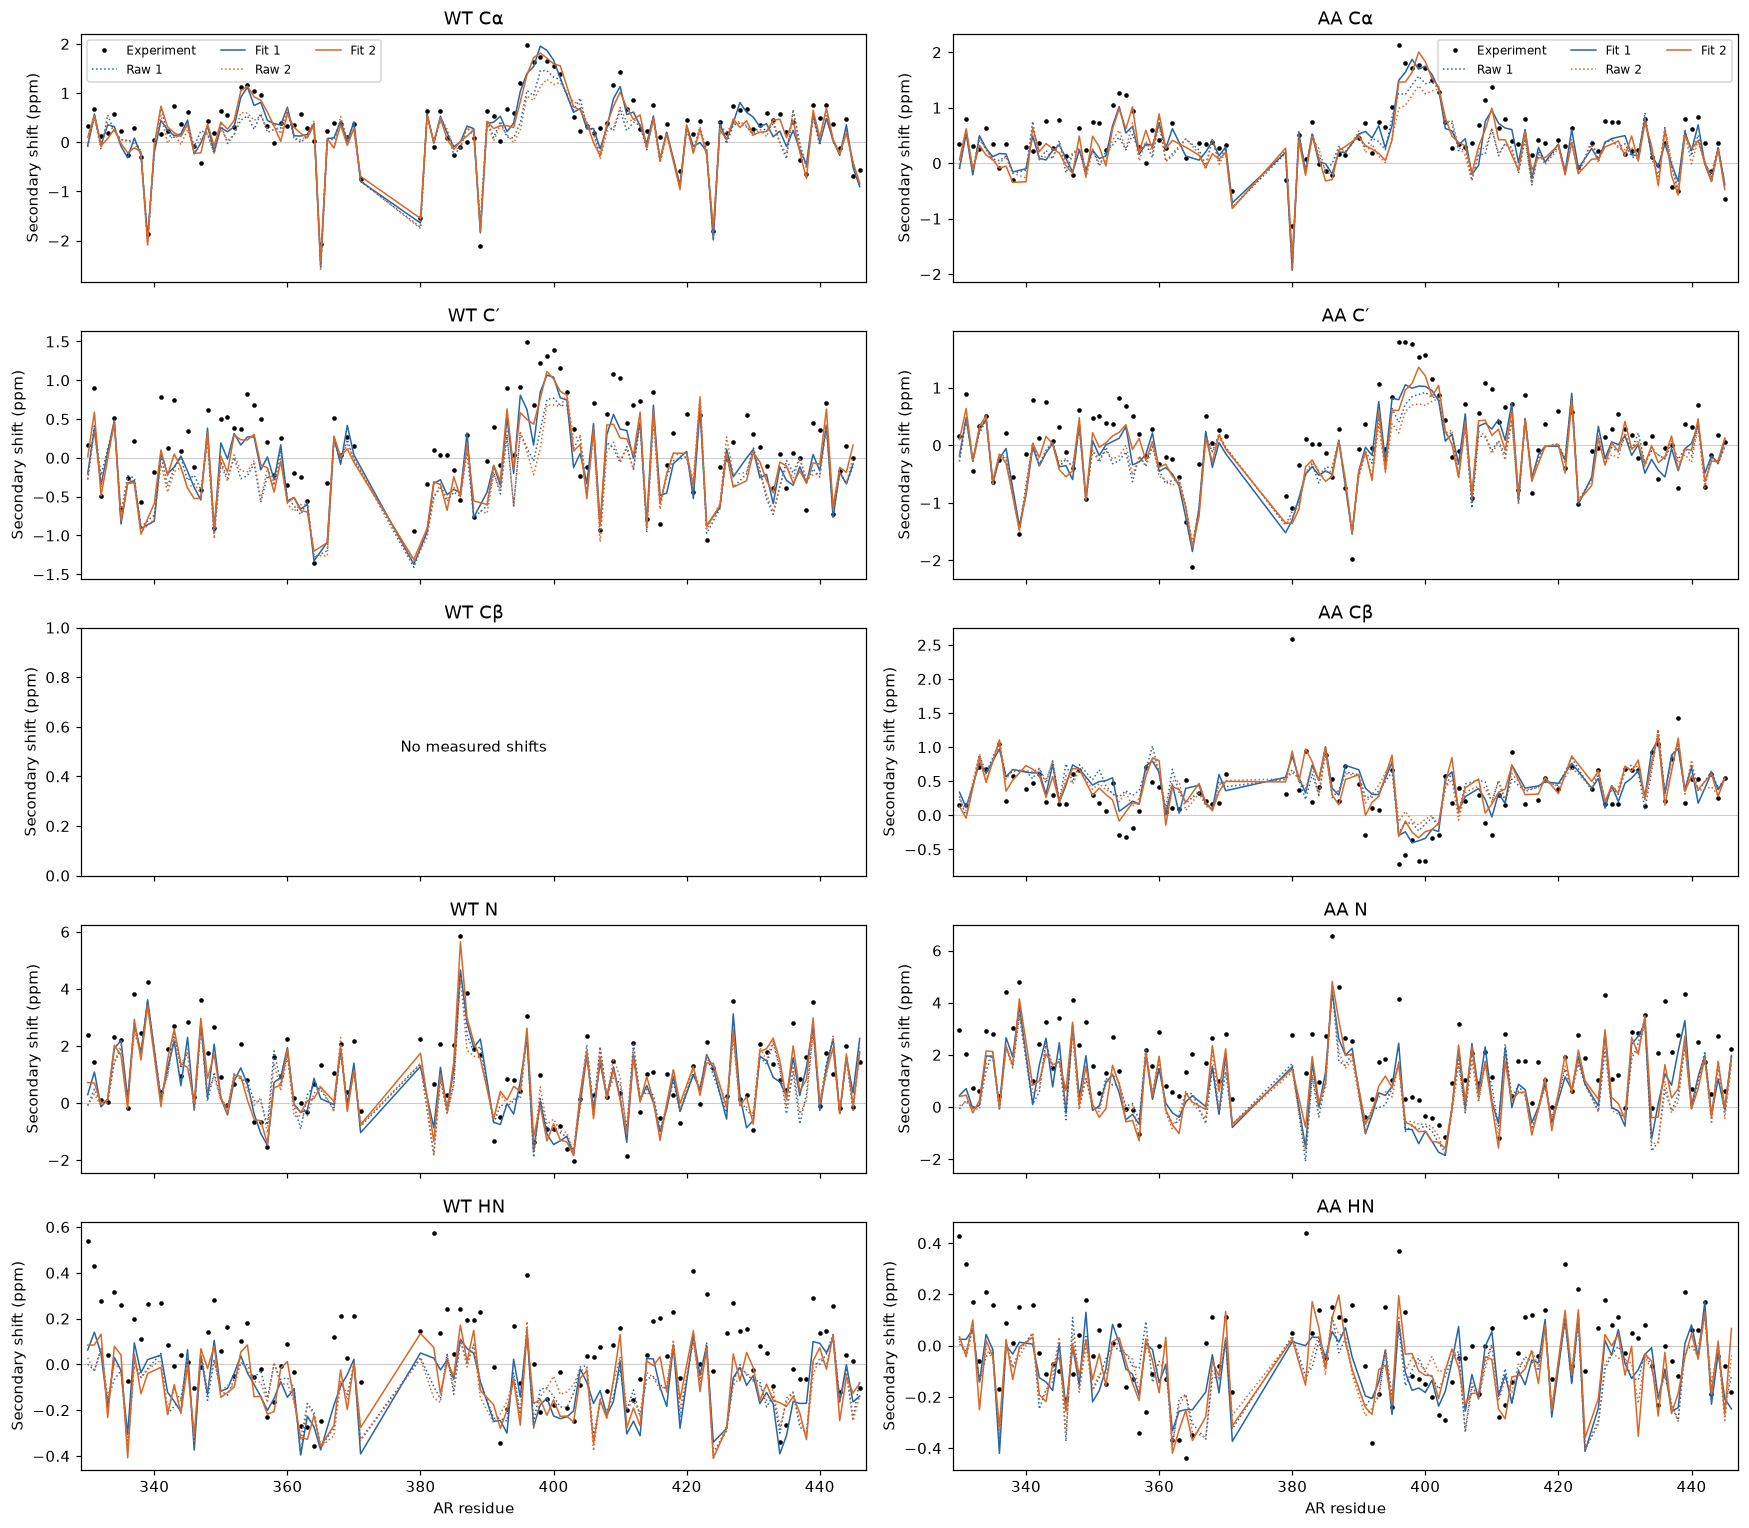

In [3]:
fig,axes=plt.subplots(5,2,figsize=(16,14),sharex=True)
for row,(atom,label) in enumerate(nuclei.items()):
    for col,s in enumerate(['WT','AA']):
        ax=axes[row,col];ax.axhline(0,color='.8',lw=.7)
        for e,color in [('1','#2466a8'),('2','#d96727')]:
            for fit,ls in [('raw',':'),('all_shifts','-')]:
                r=[r for r in data['shifts'][s] if r['atom']==atom and r['ensemble']==e and r['fit']==fit]
                if not r:continue
                x=nums(r,'AR_residue')
                if e=='1' and fit=='raw':ax.plot(x,nums(r,'experimental'),'ko',ms=2,label='Experiment')
                ax.plot(x,nums(r,'predicted'),color=color,ls=ls,lw=1,label=('Raw ' if fit=='raw' else 'Fit ')+e)
        ax.set(title=s+' '+label,ylabel='Secondary shift (ppm)',xlim=(329,447))
        if row==0:ax.legend(ncol=3,fontsize=8)
        if row==4:ax.set_xlabel('AR residue')
        if atom=='CB' and s=='WT':ax.text(.5,.5,'No measured shifts',ha='center',transform=ax.transAxes)
fig.tight_layout();plt.show()


## Experimental − calculated residuals
Each measured nucleus has its own bar plot. WT and AA share a vertical scale within each nucleus. Both fitted ensembles are shown; gray shading marks R2. No predictor-error tolerance bands are imposed.

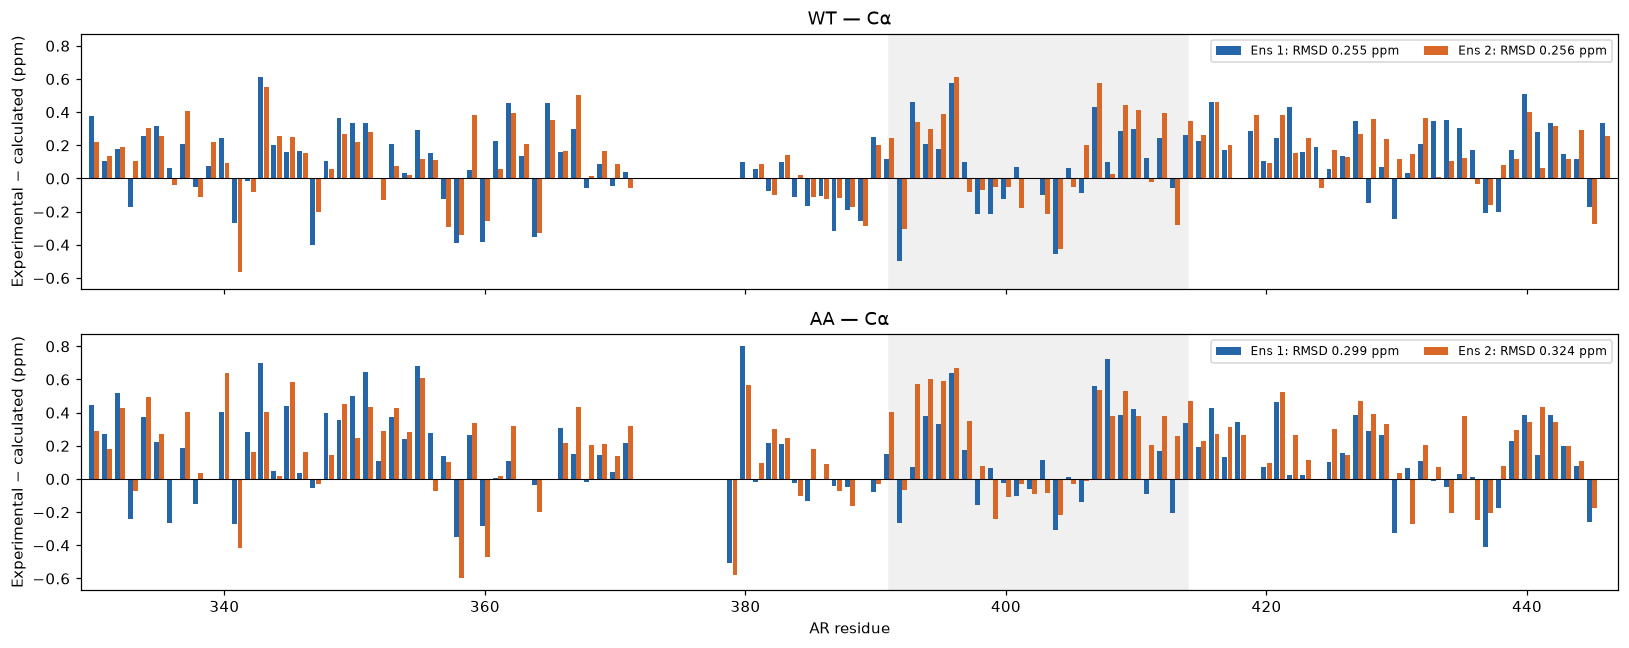

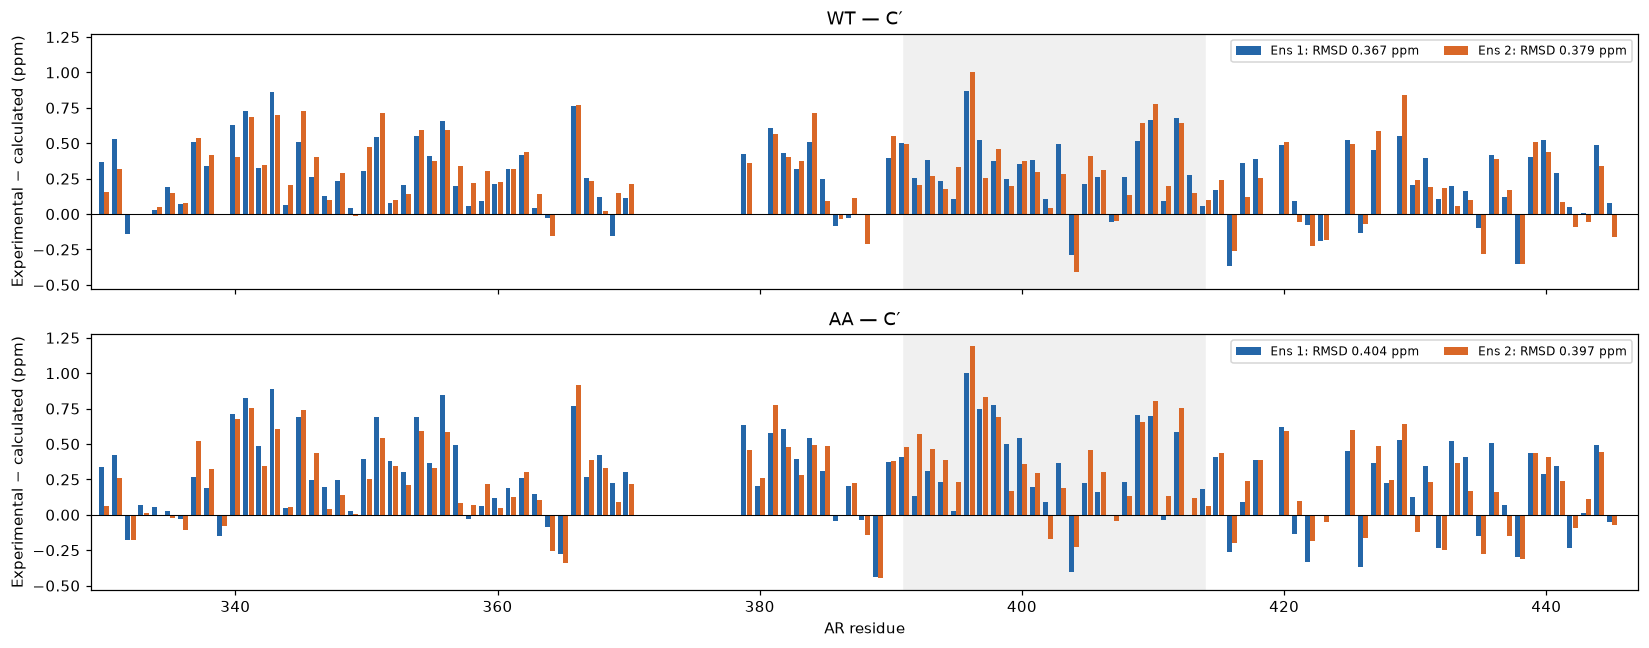

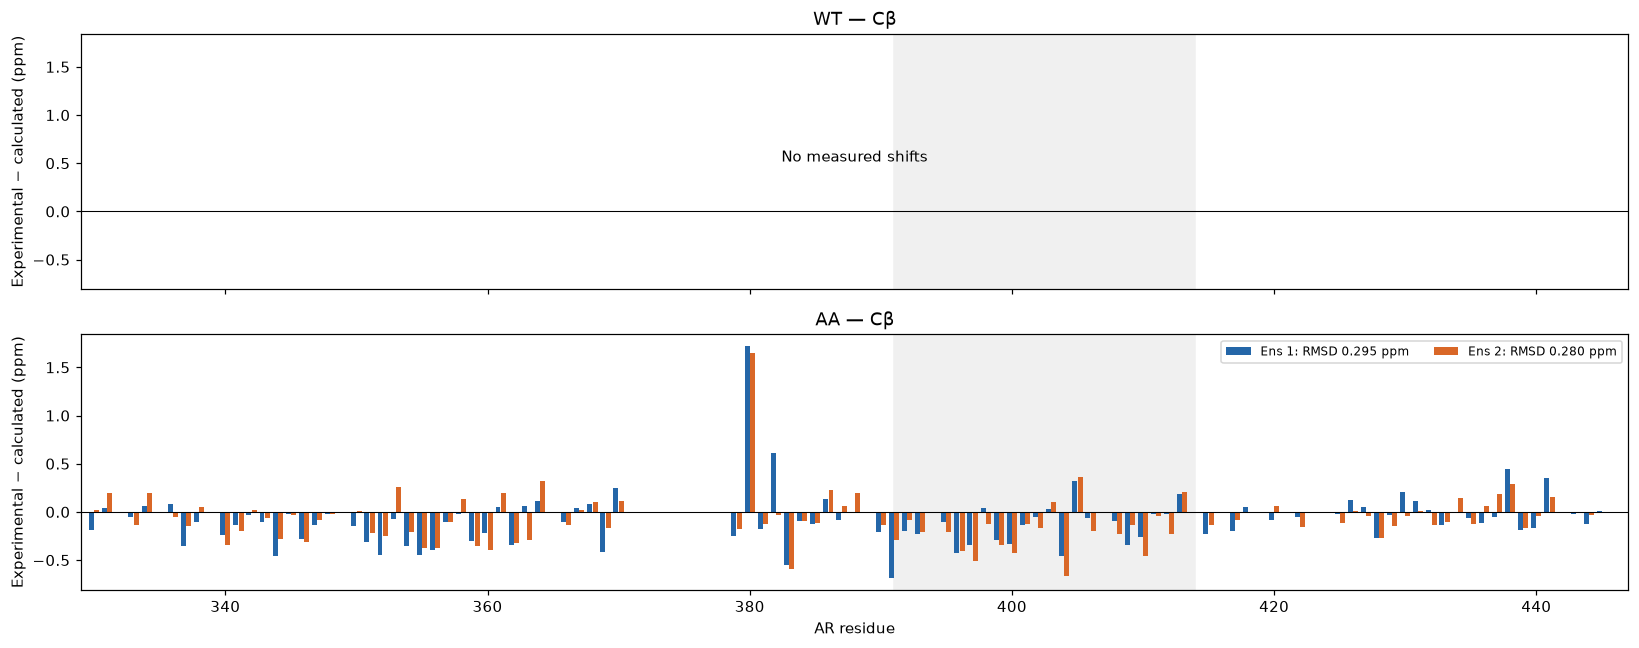

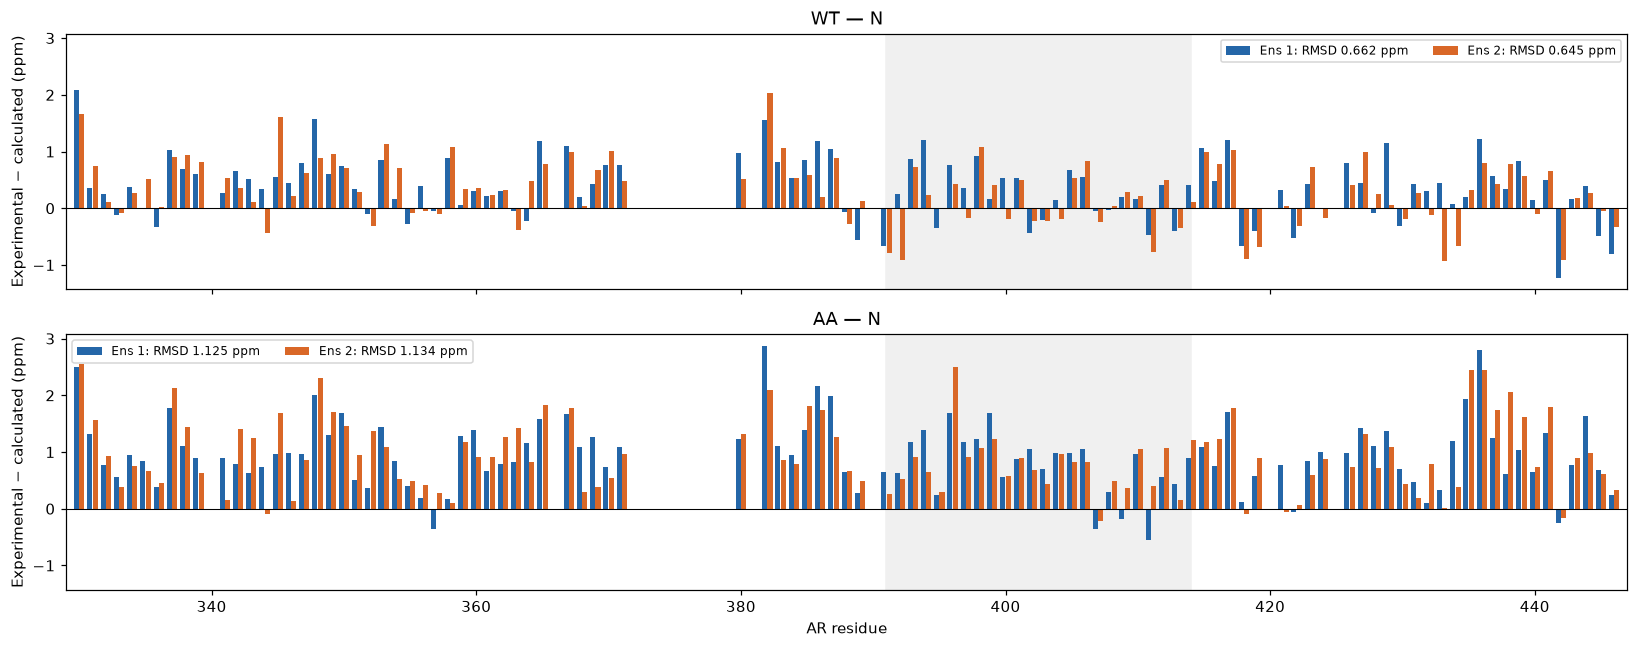

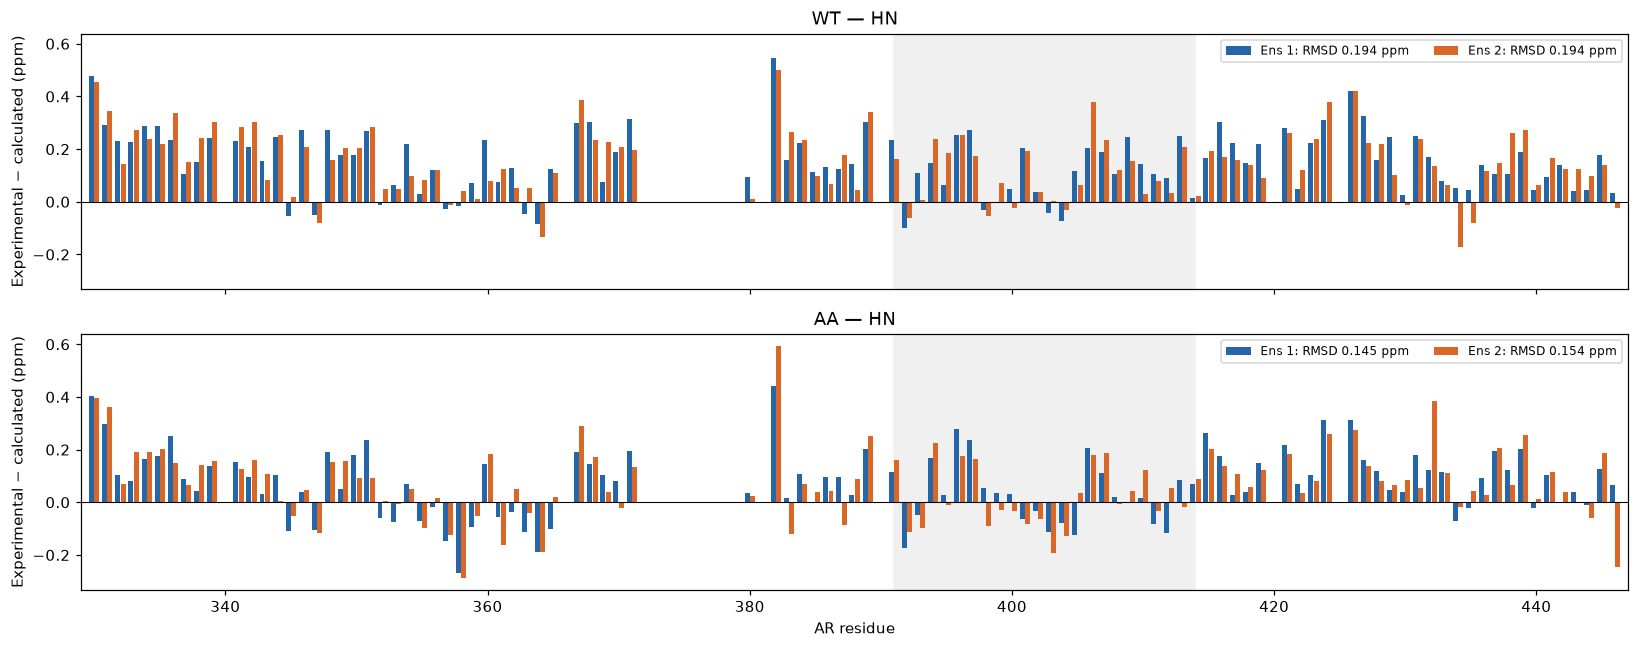

In [4]:
sign = 1
for atom,label in nuclei.items():
    fig,axes=plt.subplots(2,1,figsize=(15,6),sharex=True,sharey=True)
    for ax,s in zip(axes,['WT','AA']):
        found=False
        for e,color in [('1','#2466a8'),('2','#d96727')]:
            r=[r for r in data['shifts'][s] if r['atom']==atom and r['ensemble']==e and r['fit']=='all_shifts']
            if not r:continue
            found=True;x=nums(r,'AR_residue');residual=sign*(nums(r,'experimental')-nums(r,'predicted'))
            rms=np.sqrt(np.mean(residual**2))
            ax.bar(x+(-.2 if e=='1' else .2),residual,width=.38,color=color,label=f'Ens {e}: RMSD {rms:.3f} ppm')
        ax.axhline(0,color='black',lw=.7);ax.axvspan(391,414,color='.94',zorder=0)
        ax.set(title=s+' — '+label,ylabel='Experimental − calculated (ppm)',xlim=(329,447))
        if found:ax.legend(ncol=2,fontsize=8)
        else:ax.text(.5,.5,'No measured shifts',ha='center',transform=ax.transAxes)
    axes[-1].set_xlabel('AR residue');fig.tight_layout()
plt.show()


## Calculated − experimental residuals
Each measured nucleus has its own bar plot. WT and AA share a vertical scale within each nucleus. Both fitted ensembles are shown; gray shading marks R2. No predictor-error tolerance bands are imposed.

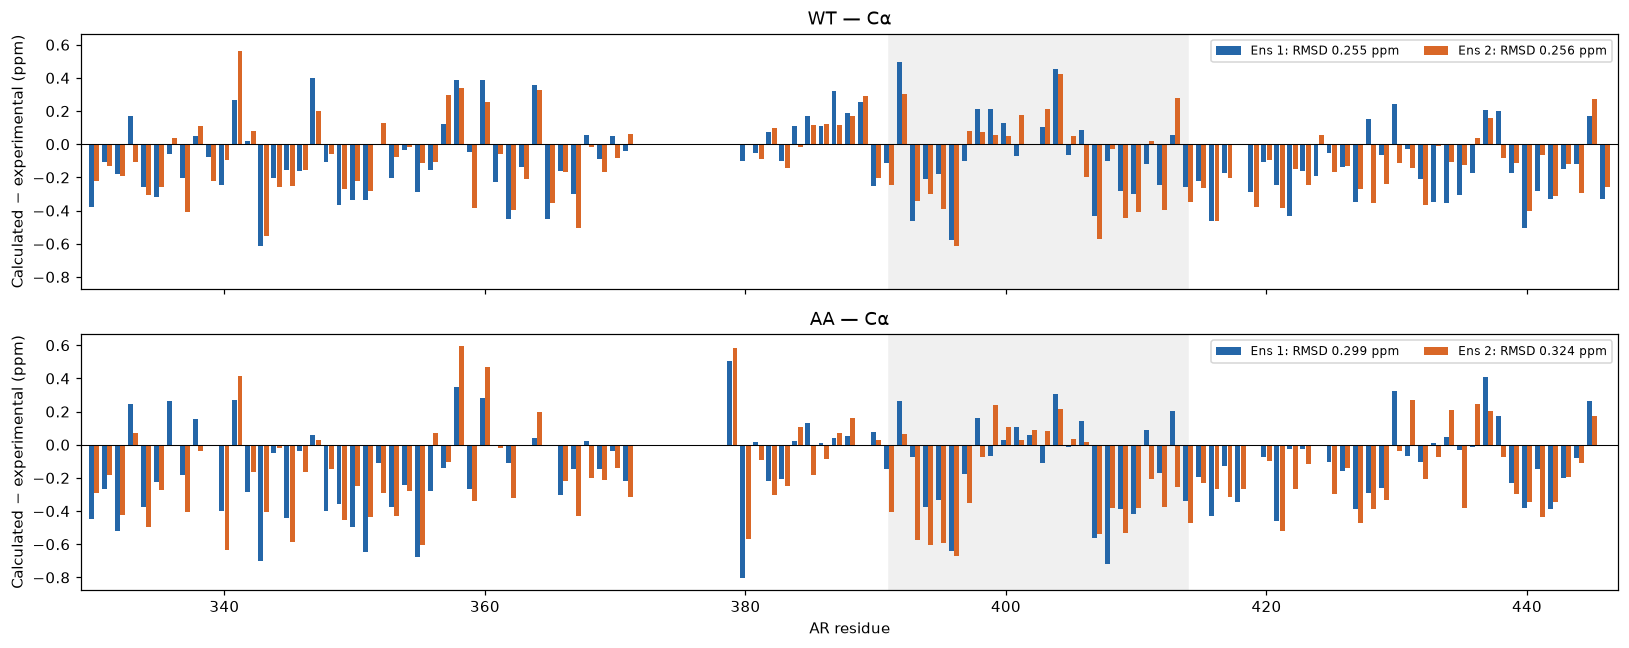

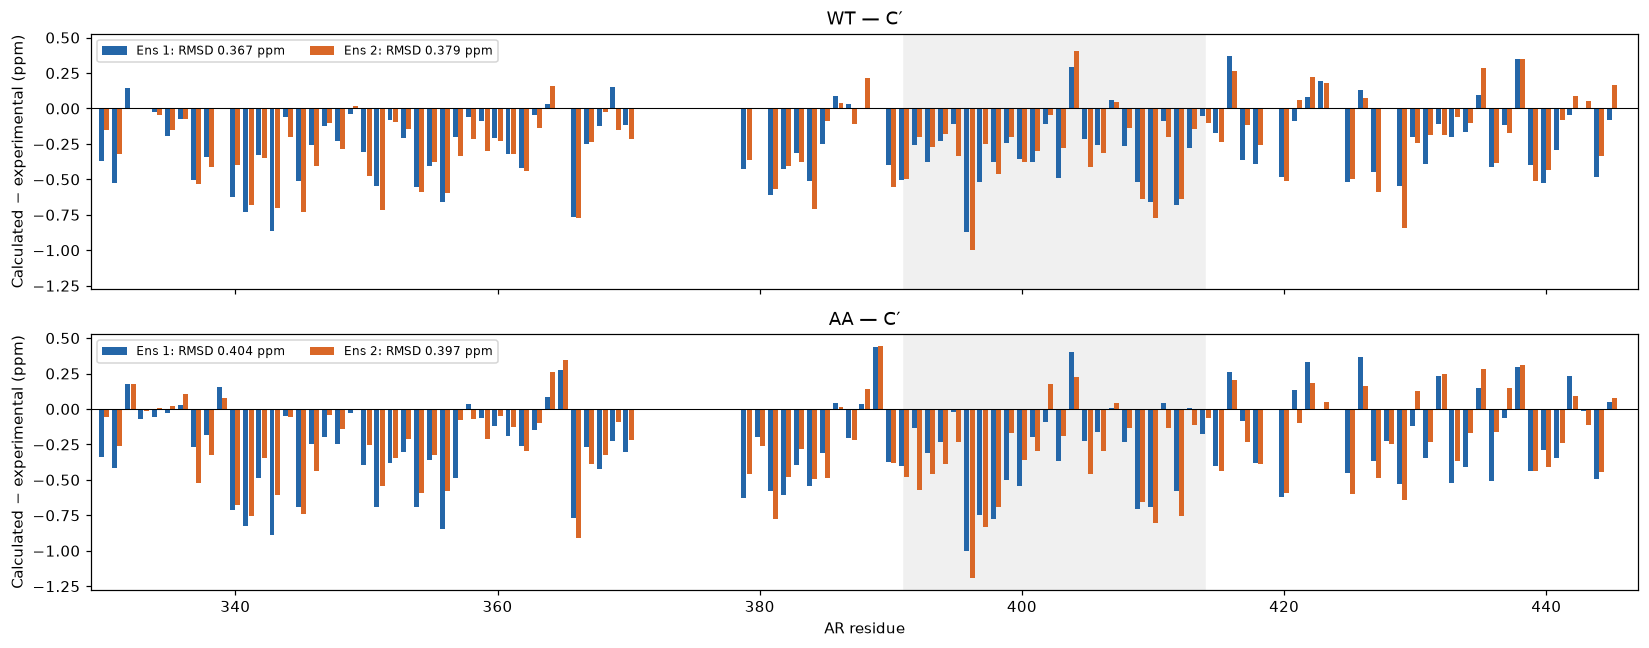

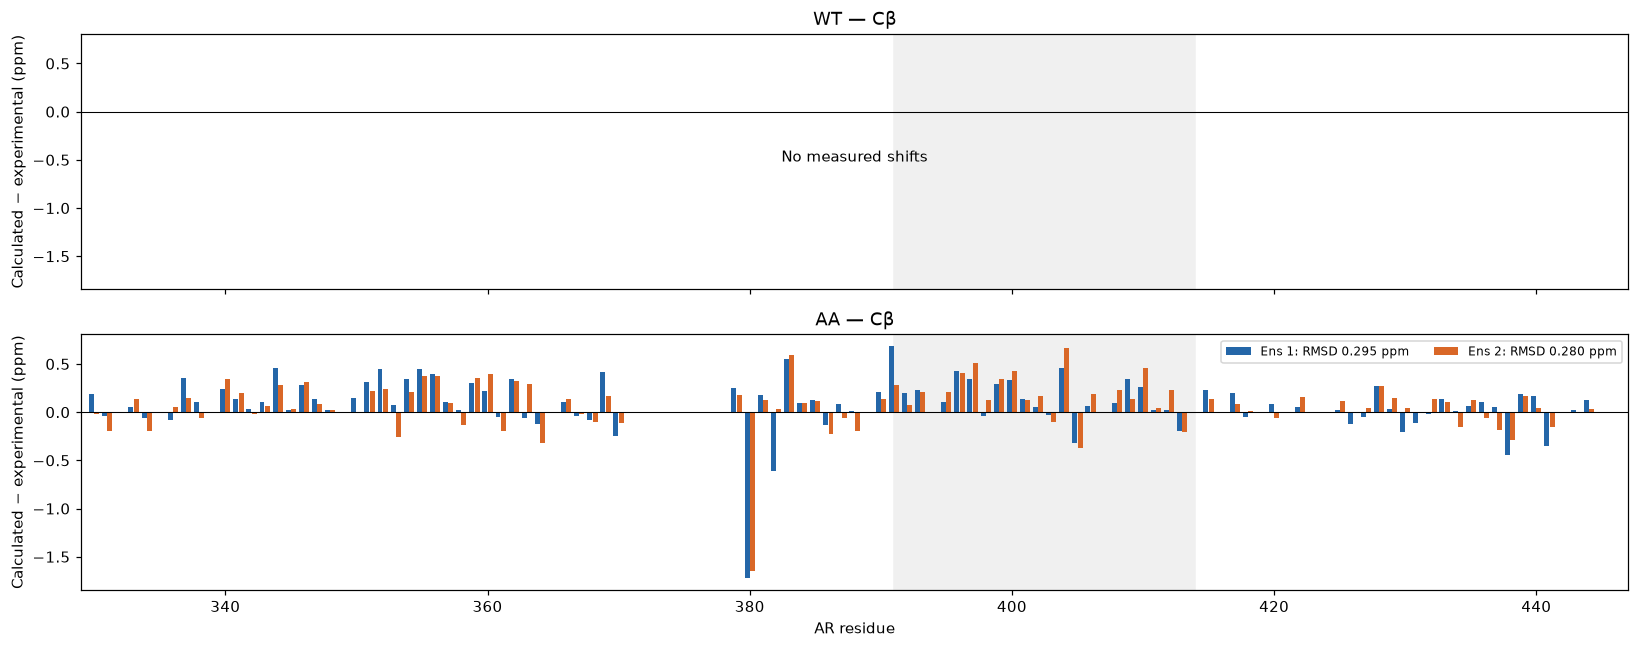

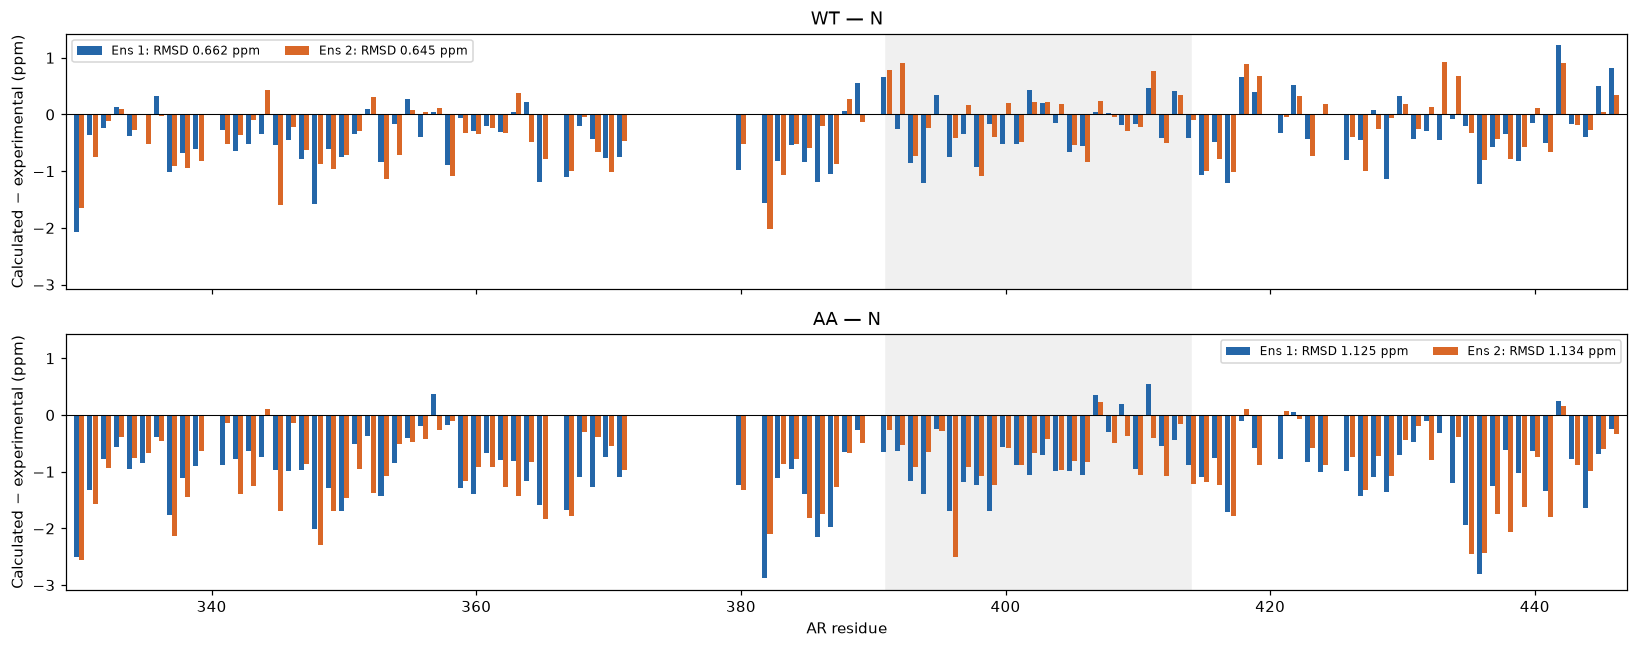

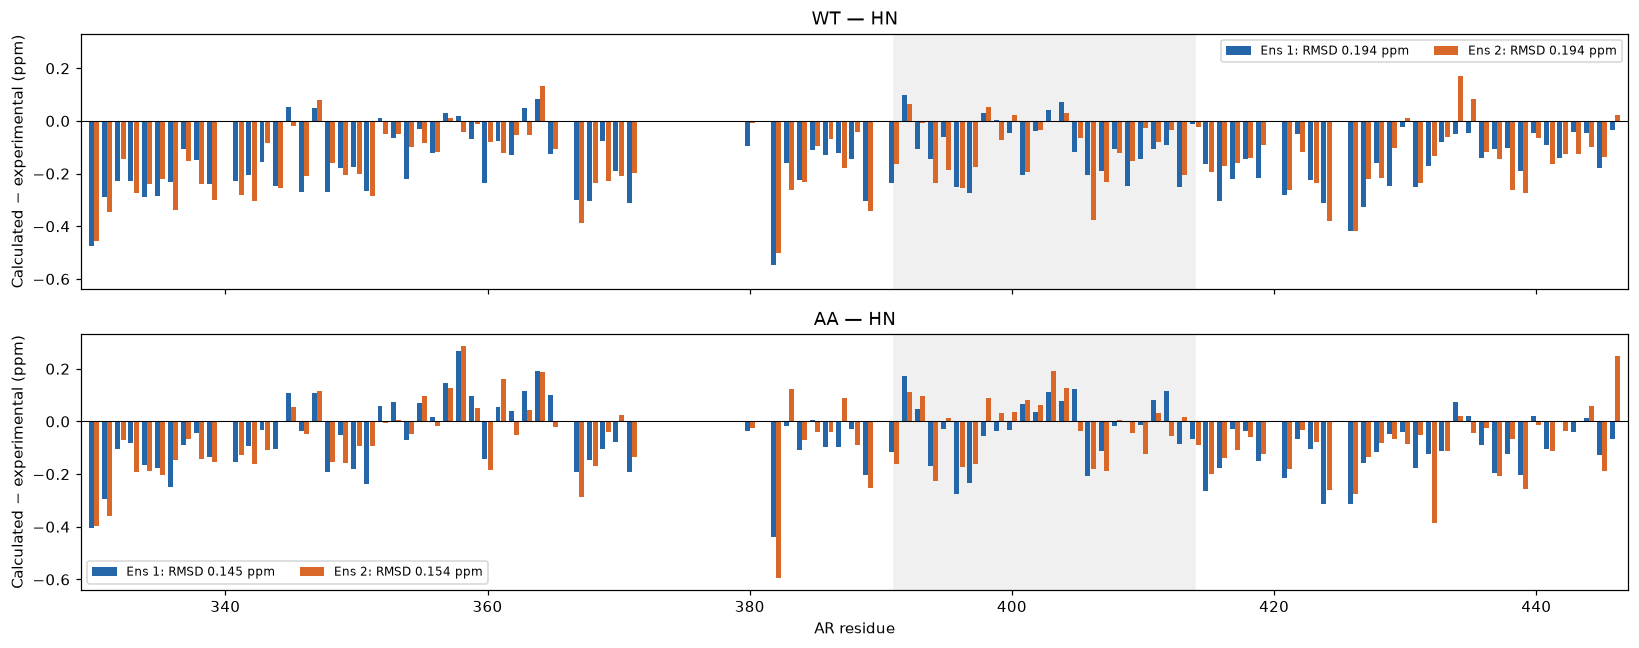

In [5]:
sign = -1
for atom,label in nuclei.items():
    fig,axes=plt.subplots(2,1,figsize=(15,6),sharex=True,sharey=True)
    for ax,s in zip(axes,['WT','AA']):
        found=False
        for e,color in [('1','#2466a8'),('2','#d96727')]:
            r=[r for r in data['shifts'][s] if r['atom']==atom and r['ensemble']==e and r['fit']=='all_shifts']
            if not r:continue
            found=True;x=nums(r,'AR_residue');residual=sign*(nums(r,'experimental')-nums(r,'predicted'))
            rms=np.sqrt(np.mean(residual**2))
            ax.bar(x+(-.2 if e=='1' else .2),residual,width=.38,color=color,label=f'Ens {e}: RMSD {rms:.3f} ppm')
        ax.axhline(0,color='black',lw=.7);ax.axvspan(391,414,color='.94',zorder=0)
        ax.set(title=s+' — '+label,ylabel='Calculated − experimental (ppm)',xlim=(329,447))
        if found:ax.legend(ncol=2,fontsize=8)
        else:ax.text(.5,.5,'No measured shifts',ha='center',transform=ax.transAxes)
    axes[-1].set_xlabel('AR residue');fig.tight_layout()
plt.show()


## SAXS: current predictions versus earlier joint fits
The current direct-fit weights were not selected against SAXS. A single intensity scale is optimized per curve; there is no additive background. χ² denotes mean squared residual divided by experimental σ², not a degrees-of-freedom-corrected statistic. Earlier joint fits use different, pooled candidate sets.

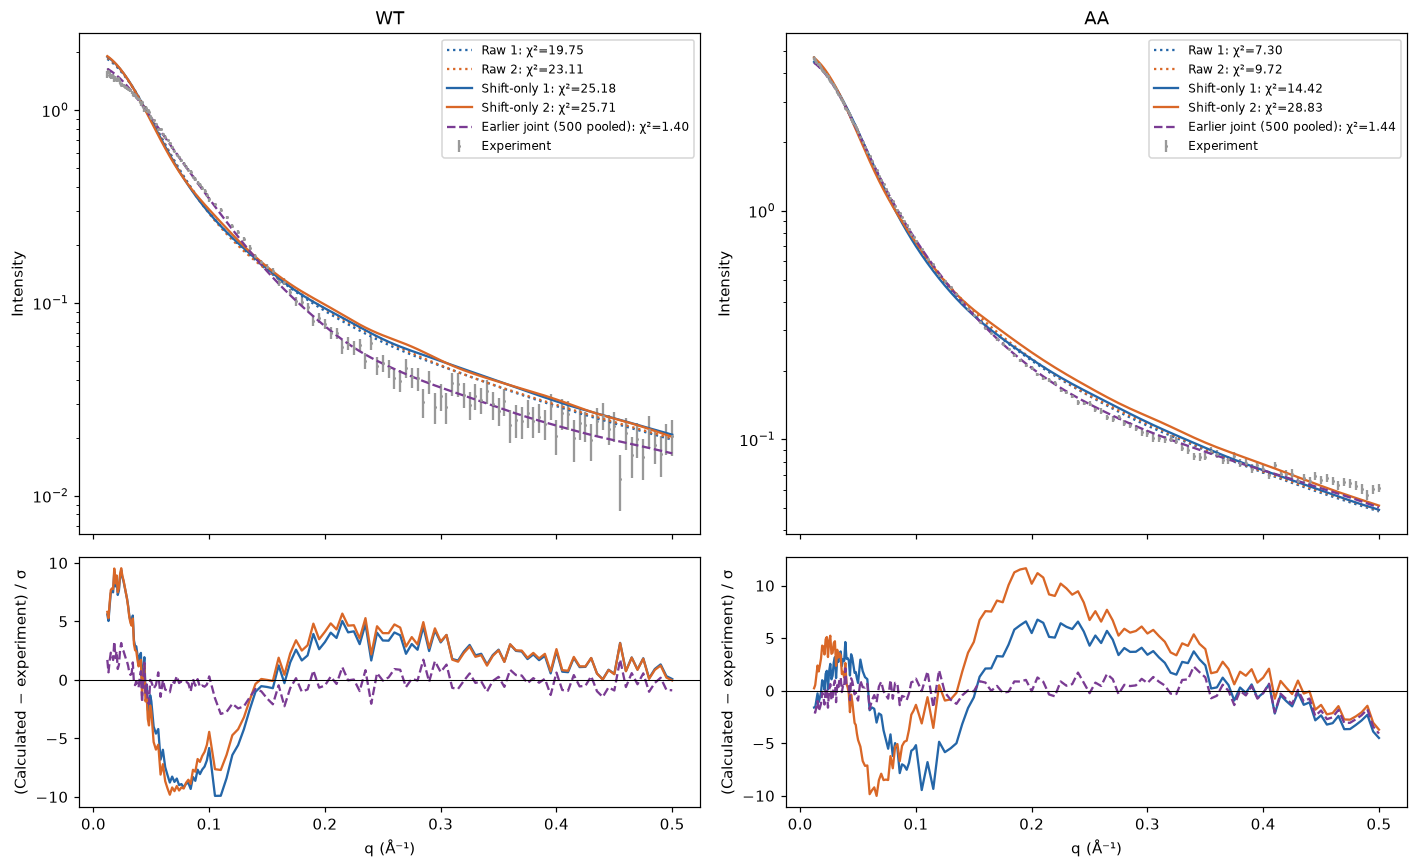

In [6]:
fig,axes=plt.subplots(2,2,figsize=(13,8),sharex='col',gridspec_kw={'height_ratios':[2,1]})
for col,s in enumerate(['WT','AA']):
    r=data['saxs'][s];q=nums(r,'q_Ainv');y=nums(r,'I_exp');sigma=nums(r,'sigma_exp');ax=axes[0,col];res=axes[1,col]
    ax.errorbar(q,y,yerr=sigma,fmt='.',ms=2,color='.6',label='Experiment')
    for key,label,color,ls in [('raw_1','Raw 1','#2466a8',':'),('raw_2','Raw 2','#d96727',':'),('all_shifts_1','Shift-only 1','#2466a8','-'),('all_shifts_2','Shift-only 2','#d96727','-'),('earlier_joint','Earlier joint (500 pooled)','#7a3b93','--')]:
        pred=nums(r,key);z=(pred-y)/sigma;chi=np.mean(z*z)
        ax.plot(q,pred,color=color,ls=ls,label=f'{label}: χ²={chi:.2f}')
        if not key.startswith('raw'):res.plot(q,z,color=color,ls=ls)
    ax.set(yscale='log',title=s,ylabel='Intensity');ax.legend(fontsize=8)
    res.axhline(0,color='black',lw=.7);res.set(xlabel='q (Å⁻¹)',ylabel='(Calculated − experiment) / σ')
fig.tight_layout();plt.show()


## Numerical summaries and provenance
Direct-fit RMSDs below are calculated against every retained shift for each nucleus. These are fit residuals, not independent validation. Candidate weights and sequence/numbering audits accompany this notebook. Coordinates and licensed SPARTA+ software are not bundled in this snapshot. The scripts directory preserves the local analysis implementations; these scripts require the original workspace inputs, whereas this notebook reruns using only snapshot_data.json, NumPy, and Matplotlib.

In [7]:
for s in ['WT','AA']:
    print(s)
    for r in data['summary'][s]['ensembles']:
        if r['label']=='all_shifts':
            print(' Ensemble',r['ensemble'],'candidates',r['n_candidates'],'Kish effective size',round(r['kish_effective_size'],1))
            print(' RMSD (ppm):', {k:round(v,3) for k,v in r['RMSD_ppm'].items()})
            print(' SAXS χ² per point:',round(r['saxs_chi2_mean'],2))


WT
 Ensemble 1 candidates 300 Kish effective size 34.5
 RMSD (ppm): {'C': 0.367, 'CA': 0.255, 'N': 0.662, 'NH': 0.194}
 SAXS χ² per point: 25.18
 Ensemble 2 candidates 250 Kish effective size 34.5
 RMSD (ppm): {'C': 0.379, 'CA': 0.256, 'N': 0.645, 'NH': 0.194}
 SAXS χ² per point: 25.71
AA
 Ensemble 1 candidates 299 Kish effective size 38.4
 RMSD (ppm): {'C': 0.404, 'CA': 0.299, 'CB': 0.295, 'N': 1.125, 'NH': 0.145}
 SAXS χ² per point: 14.42
 Ensemble 2 candidates 250 Kish effective size 35.5
 RMSD (ppm): {'C': 0.397, 'CA': 0.324, 'CB': 0.28, 'N': 1.134, 'NH': 0.154}
 SAXS χ² per point: 28.83
